# 1. Keras 텍스트 전처리
    1. [수치 데이터로 변환] 텍스트 토큰화 및 정수 인코딩
    2. [같은 길이로 만들기] 패딩 (padding)

In [1]:
# tensorflow 설치 확인
import tensorflow
tensorflow.__version__

'2.20.0'

In [4]:
# 연습 샘플
# texts = [
#     "나는 학교에 간다",
#     "너는 도서관에 간다",
#     "그는 시장에 간다"
# ]
texts = [ ["나", "학교", "가"], ["너", "도서관", "가"], ["그", "시장", "가"]]

## 1-1. 텍스트 데이터 Integer Encoding
- num_words = 사용할 단어 수 + 1

In [ ]:
# Tokenizer 객체 생성 (특징 벡터용 단어 수와 OOV 토큰 지정)
from tensorflow.keras.preprocessing.text import Tokenizer

# 특징 집합 생성 및 정수 indexing
tokenizer = Tokenizer(num_words=5)
tokenizer.fit_on_texts(texts)
print('단어 인덱스 : ', tokenizer.word_index)

# 입력 텍스트 리스트의 integer encoding
encoded_texts = tokenizer.texts_to_sequences(texts)
print('정수 인코딩된 텍스트(시퀀스) : ', encoded_texts)

단어 인덱스 :  {'가': 1, '나': 2, '학교': 3, '너': 4, '도서관': 5, '그': 6, '시장': 7}
정수 인코딩된 텍스트(시퀀스) :  [[2, 3, 1], [4, 1], [1]]


## 1-2. Padding : 입력 시퀀스의 길이를 동일하게 조정하기

In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_texts = pad_sequences(encoded_texts, maxlen=3)
print('패딩된 시퀀스 : ', padded_texts)

패딩된 시퀀스 :  [[2 3 1]
 [0 4 1]
 [0 0 1]]


## 1-3. 정답 데이터 One-hot Encoding

In [9]:
label = [1, 0, 2, 5, 0, 2, 3]

from tensorflow.keras.utils import to_categorical

one_hot_label = to_categorical(label)
print('레이블의 one-hot vector : ', one_hot_label)


레이블의 one-hot vector :  [[0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]]


# 2. 텍스트 전처리를 위한 파라미터 결정하기
- Integer Encoding을 위한 단어(특징) 집합의 크기 정하기 (Tokenizer의 num_words)
- Padding을 위한 시퀀스 길이 정하기 (pad_sequences의 max_len) 

In [10]:
# 데이터 로딩 및 실습 데이터 추출
import pandas as pd
texts = list(pd.read_csv('./data/Korean_movie_reviews_2016.csv').review)
texts[:2]

['부산 행 때문 너무 기대하고 봤', '한국 좀비 영화 어색하지 않게 만들어졌 놀랍']

## 2-1. 단어 집합의 크기 정하기 (Tokenizer의 num_words)
등장 빈도수가 기준값(threshold)보다 적은 단어의 비중을 확인하여 정하기
1. corpus의 전체 단어 수 (total_cnt)와 전체 빈도수 (total_freq) 계산
2. threshold보다 빈도수가 적은 단어수 카운트 (rare_cnt)와 빈도수 (rare_freq) 계산
3. 희귀 단어의 비율(rare_cnt/total_cnt)과 희귀 등장 빈도 비율 계산(rare_freq/total_freq)
4. 희귀 단어를 뺀 단어 수 -> 단어 집합의 크기 산정

In [13]:
# Tokenizer로 단어-빈도 사전 생성
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(texts)
len(test_tokenizer.word_counts)

52011

In [29]:
# 등장 빈도수가 threshold회 미만인 단어들이 이 데이터에서 얼만큼의 비중을 차지하는지 확인
from lib.my_utils import word_status_below_threshold

threshold = 3
word_status_below_threshold(test_tokenizer, threshold)

=== 빈도수가 3번 이상인 단어만 사용하는 경우 ====
전체 단어 : 52,011개 1,888,659번
희귀 단어 : 29,364개 (56.46%) 35,871번 (1.90%)
사용할 단어 : 22,647개 (43.54%)    1,852,788번 (98.10%)


## 2-2. Padding 길이 정하기 (pad_sequences의 max_len)
1. 단어 길이 데이터로 DataFrame 생성
2. 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
3. 단어 길이 통계 정보 확인 (df.describe())
4. 텍스트의 길이가 설정한 max_len 이하인 비율 계산

In [35]:
texts[:5]

['부산 행 때문 너무 기대하고 봤',
 '한국 좀비 영화 어색하지 않게 만들어졌 놀랍',
 '조금 전 보고 왔 지루하다 언제 끝나 이 생각 드',
 '평 밥 끼 먹자 돈 니 내고 미친 놈 정신사 좀 알 싶어 그래 밥 먹다 먹던 숟가락 대가리 존나 때릴 지도 모르 일단 면상 확인하고 싶다 전화번호 남겨 놔 진짜',
 '점수 대가 과 이 엑소 팬 어중간 점수 줄리 없겠 클레멘타인 이후 최고 평점 조작 영화 아닐 생각 드네']

In [37]:
#단어 길이 데이터로 DataFrame 생성
import pandas as pd

len_df = pd.DataFrame()
len_list = [len(text.split()) for text in texts]
len_df['len'] = len_list
len_df.head()

,len
0,6
1,7
2,10
3,31
4,19


array([[<Axes: title={'center': 'len'}>]], dtype=object)

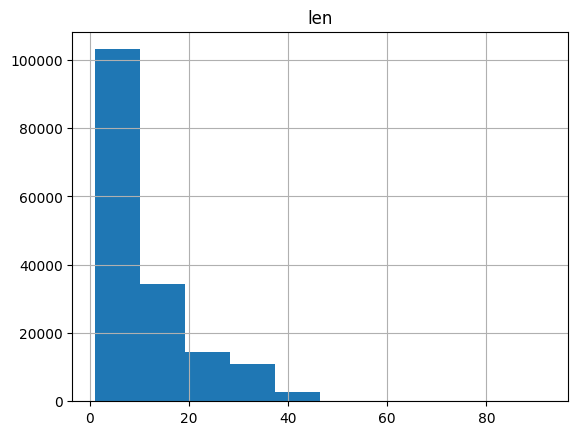

In [38]:
# 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
len_df.hist()

In [39]:
#단어 길이 통계 정보 확인 (df.describe())
len_df.describe()

,len
count,165384.000000
mean,11.419841
std,9.117849
min,1.000000
25%,5.000000
50%,8.000000
75%,15.000000
max,92.000000


In [63]:
#텍스트의 길이가 설정한 max_len 이하인 비율 계산
from lib.my_utils import text_len_status_below_maxlen

max_len = 40
text_len_status_below_maxlen([text.split() for text in texts], max_len)


텍스트의 토큰 수가 40 이하인 텍스트 : 164,697개 (99.58%)


In [62]:
import lib.my_utils, importlib 
importlib.reload(lib.my_utils)

<module 'lib.my_utils' from 'd:\\Lecture\\_AIService26\\lib\\my_utils.py'>